# 1. Dataset

8,162 photos merged from six Roboflow Universe datasets: two of fresh and rotten fruit, two of faces and two of everyday scenes (rooms, streets). The face and scene photos have no boxes. They teach the model that people and their surroundings, which fill most webcam frames, aren't fruit.

In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path[:0] = [os.getcwd(), "notebooks"]

import json
import random

import cv2
import matplotlib.pyplot as plt
import pandas as pd

import viz
from dataset_stats import count_split, dhash, list_images, load_dataset

viz.setup()
DATA = "datasets/combined/data.yaml"
splits, names = load_dataset(DATA)
images = {s: list_images(p) for s, p in splits.items()}
{s: len(v) for s, v in images.items()}

{'train': 6578, 'val': 991, 'test': 593}

## Sources

| Folder | Roboflow dataset | Role |
|---|---|---|
| RottenFruitDataset3 | [Rotten Fruit Detector v3](https://universe.roboflow.com/deep-learning-computer-vision-project/rotten-fruit-detector/dataset/3) | fruit |
| RottenFruitDataset4 | [Fresh and Rotten Fruits v3](https://universe.roboflow.com/alrz-nt-wcyue/fresh-and-rotten-fruits-aa5ae/dataset/3) | fruit |
| FaceDataset1 | [Face Detection v27](https://universe.roboflow.com/mohamed-traore-2ekkp/face-detection-mik1i/dataset/27) | no fruit |
| FaceDataset2 | [Face Detection v4](https://universe.roboflow.com/upec-gxwq3/face-detection-qb4rl/dataset/4) | no fruit |
| BackgroundDataset1 | [Room v7](https://universe.roboflow.com/techvantage-systems/room-w95vj/dataset/7) | no fruit |
| BackgroundDataset2 | [Blind Assistant v9](https://universe.roboflow.com/tazwarul/blind-assistant-vbhah/dataset/9) | no fruit |

The two fruit datasets labelled their classes differently, so both were relabelled to one scheme first (`rotten_apple, rotten_banana, rotten_orange, fresh_apple, fresh_banana, fresh_orange`). The face and scene labels were emptied. `merge_datasets.py` then combines the six folders; run on the original folders it rebuilds this dataset exactly, down to every label file.

In [2]:
sources = pd.DataFrame(json.loads(Path("results/combined_sources.json").read_text())).T
for split in ("train", "valid", "test"):
    sources[split] = pd.to_numeric(sources[split]).fillna(0).astype(int)
sources.loc["total"] = ["", *sources[["train", "valid", "test"]].sum()]
merged = {"train": len(images["train"]), "valid": len(images["val"]), "test": len(images["test"])}
print("combined dataset:", merged, "| matches the sum of the sources:",
      all(sources.loc["total", k] == v for k, v in merged.items()))
sources

combined dataset: {'train': 6578, 'valid': 991, 'test': 593} | matches the sum of the sources: True


,role,train,valid,test
RottenFruitDataset3,fruit,2316,658,330
RottenFruitDataset4,fruit,1986,190,96
FaceDataset1,negative,104,38,0
FaceDataset2,negative,771,19,108
BackgroundDataset1,negative,105,10,5
BackgroundDataset2,negative,1296,76,54
total,,6578,991,593


## Classes and splits

In [3]:
stats = {s: count_split(files, names) for s, files in images.items()}
table = pd.DataFrame({s: v["per_class"] for s, v in stats.items()})
table.loc["boxes"] = [v["instances"] for v in stats.values()]
table.loc["photos"] = [v["images"] for v in stats.values()]
table.loc["photos with no fruit"] = [v["backgrounds"] for v in stats.values()]
table

,train,val,test
rotten_apple,1139,208,112
rotten_banana,1805,264,167
rotten_orange,1408,332,142
fresh_apple,1032,183,89
fresh_banana,1647,387,201
fresh_orange,1514,384,159
boxes,8545,1758,870
photos,6578,991,593
photos with no fruit,2291,144,170


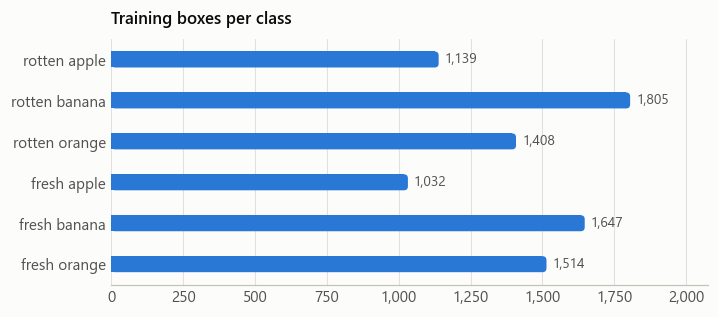

In [4]:
train = pd.Series(stats["train"]["per_class"])
fig, ax = plt.subplots(figsize=(7, 2.9))
viz.hbars(ax, [n.replace("_", " ") for n in train.index], train.to_numpy())
ax.set_title("Training boxes per class")
viz.render(fig)

## Checks

In [5]:
print("invalid boxes (negative size or outside the photo):", {s: v["invalid_boxes"] for s, v in stats.items()})
train_hashes = {dhash(f) for f in images["train"]}
print("val/test photos that are copies of training photos:",
      {s: sum(dhash(f) in train_hashes for f in images[s]) for s in ("val", "test")})

invalid boxes (negative size or outside the photo): {'train': 0, 'val': 0, 'test': 0}
val/test photos that are copies of training photos: {'val': 0, 'test': 1}


The one test photo that also appears in training changes nothing measurable, so the test split is used as is.

## Samples

Training photos with their boxes:

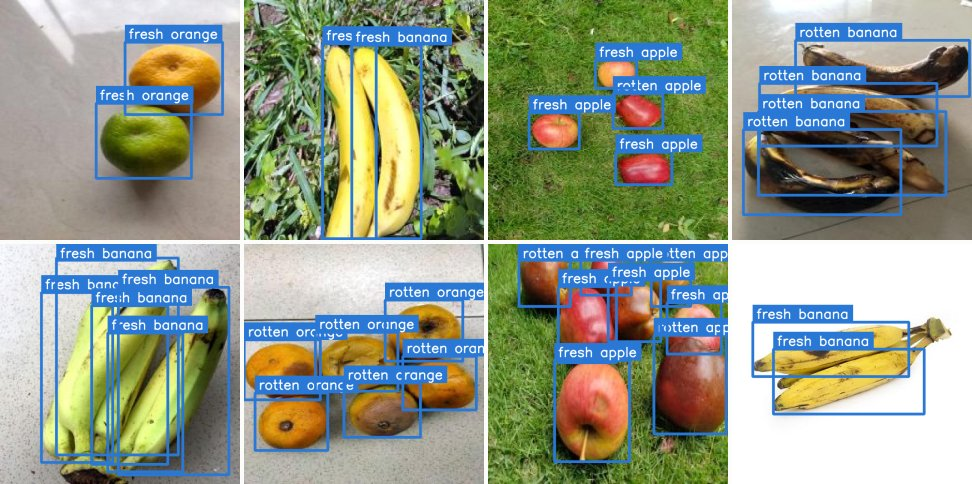

In [6]:
def load_labels(img_path):
    lines = (img_path.parent.parent / "labels" / f"{img_path.stem}.txt").read_text().splitlines()
    return [(int(c), [float(v) for v in box]) for c, *box in (l.split() for l in lines if l.strip())]


random.seed(4)
fruit = [p for p in images["train"] if len(load_labels(p)) >= 2]
tiles = []
for p in random.sample(fruit, 8):
    img = cv2.imread(str(p))
    H, W = img.shape[:2]
    for c, box in load_labels(p):
        viz.draw_box(img, viz.yolo_to_xyxy(box, W, H), viz.BLUE, names[c].replace("_", " "))
    tiles.append(img)
viz.grid(tiles, cols=4, tile=240)

And photos with no fruit, from the face and scene datasets:

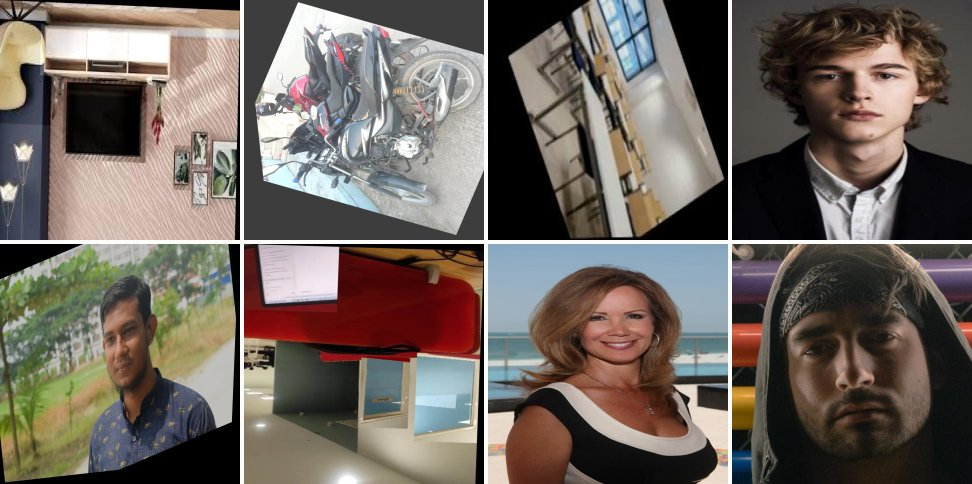

In [7]:
random.seed(5)
empty = [p for p in images["train"] if not load_labels(p)]
viz.grid([cv2.imread(str(p)) for p in random.sample(empty, 8)], cols=4, tile=240)

## 3-class version

`prepare_data.py --classes 3` merges fresh and rotten into apple, banana and orange for the 3-class model (`datasets/combined-3class`). Same photos, same boxes.

In [8]:
splits3, names3 = load_dataset("datasets/combined-3class/data.yaml")
pd.DataFrame({s: count_split(list_images(p), names3)["per_class"] for s, p in splits3.items()})

,train,val,test
apple,2171,391,201
banana,3452,651,368
orange,2922,716,301
